# Proyecto Series Temporales

# Paso 1: Carga del dataset

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from math import sqrt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX


from sklearn.metrics import mean_absolute_error, mean_squared_error

url = "https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv"
df = pd.read_csv(url)
df.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [2]:
df.shape

(366, 2)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    str    
 1   sales   366 non-null    float64
dtypes: float64(1), str(1)
memory usage: 5.8 KB


In [4]:
df.describe()

,sales
count,366.000000
mean,524.963968
std,275.089698
min,53.803211
25%,290.186822
50%,520.699468
75%,763.289263
max,1000.482785


# Paso 2: Construcción y análisis de la serie temporal

In [5]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

# Aseguramos frecuencia diaria en la serie objetivo
ts = df["sales"].asfreq("D")

print("Filas:", len(ts))
print("Rango:", ts.index.min(), "->", ts.index.max())
display(ts.head())
display(ts.tail())

Filas: 366
Rango: 2022-09-03 17:10:08.079328 -> 2023-09-03 17:10:08.079328


date
2022-09-03 17:10:08.079328    55.292157
2022-09-04 17:10:08.079328    53.803211
2022-09-05 17:10:08.079328    58.141693
2022-09-06 17:10:08.079328    64.530899
2022-09-07 17:10:08.079328    66.013633
Freq: D, Name: sales, dtype: float64

date
2023-08-30 17:10:08.079328     989.600354
2023-08-31 17:10:08.079328     994.987326
2023-09-01 17:10:08.079328     995.814415
2023-09-02 17:10:08.079328     997.350214
2023-09-03 17:10:08.079328    1000.482785
Freq: D, Name: sales, dtype: float64

In [6]:
print("\nDiferencias entre fechas:")
print(ts.index.to_series().diff().value_counts().head(10))


Diferencias entre fechas:
date
1 days    365
Name: count, dtype: int64


### Pregunta 1: ¿Cuál es el tensor de la serie temporal?
El tensor de la serie temporal es diario, ya que la diferencia entre observaciones consecutivas es de 1 día.

In [7]:
print("Valores nulos en la serie:")
print(ts.isnull().sum())

Valores nulos en la serie:
0


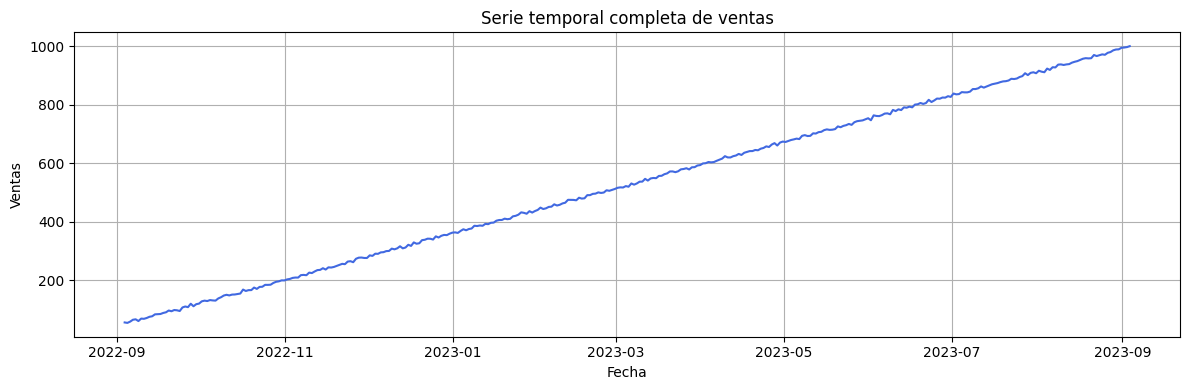

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(ts, color="royalblue")
plt.title("Serie temporal completa de ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(True)
plt.tight_layout()
plt.show()

## Separar entrenamiento y prueba

In [9]:
test_size = 60
train = ts.iloc[:-test_size]
test = ts.iloc[-test_size:]

print("Train:", train.index.min(), "->", train.index.max(), "|", len(train), "observaciones")
print("Test :", test.index.min(), "->", test.index.max(),  "|", len(test), "observaciones")

Train: 2022-09-03 17:10:08.079328 -> 2023-07-05 17:10:08.079328 | 306 observaciones
Test : 2023-07-06 17:10:08.079328 -> 2023-09-03 17:10:08.079328 | 60 observaciones


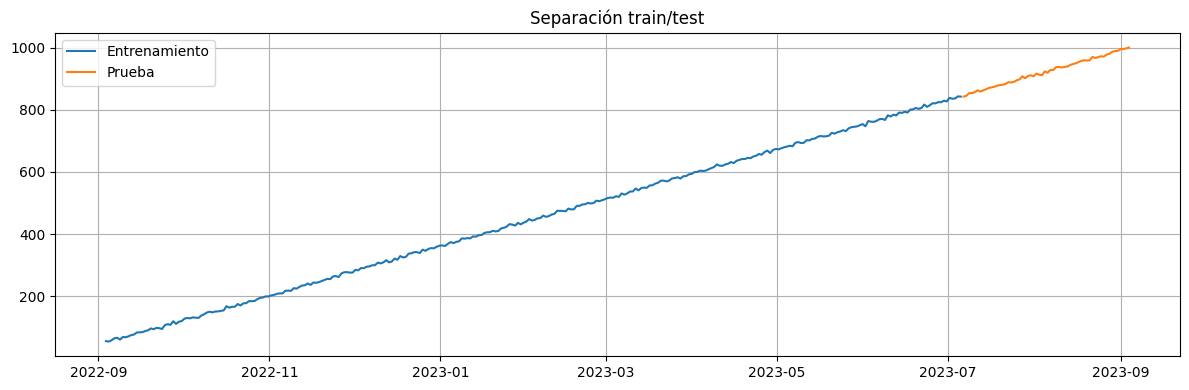

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(train, label="Entrenamiento")
plt.plot(test, label="Prueba")
plt.title("Separación train/test")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Pregunta 2: ¿Cuál es la tendencia?

La serie presenta una tendencia creciente, ya que las ventas muestran un comportamiento ascendente con el paso del tiempo.

## Prueba de estacionariedad ADF sobre train

In [11]:
def adf_report(series, name="serie"):
    result = adfuller(series.dropna(), autolag="AIC")
    report = pd.Series(
        result[0:4],
        index=["test_statistic", "p_value", "lags_used", "n_obs"]
    )
    
    for key, value in result[4].items():
        report[f"critical_value_{key}"] = value

    print(f"Resultado ADF para {name}")
    display(report)

    if report["p_value"] < 0.05:
        print("Conclusión: rechazamos H0 -> la serie puede considerarse estacionaria.")
    else:
        print("Conclusión: NO rechazamos H0 -> la serie parece no estacionaria.")

adf_report(train, "train")

Resultado ADF para train


test_statistic          0.339807
p_value                 0.979099
lags_used               7.000000
n_obs                 298.000000
critical_value_1%      -3.452486
critical_value_5%      -2.871288
critical_value_10%     -2.571964
dtype: float64

Conclusión: NO rechazamos H0 -> la serie parece no estacionaria.


### Pregunta 3: ¿Es estacionaria?

Con p-value alto, la serie parece no estacionaria.

## Descomposición de la serie sobre train

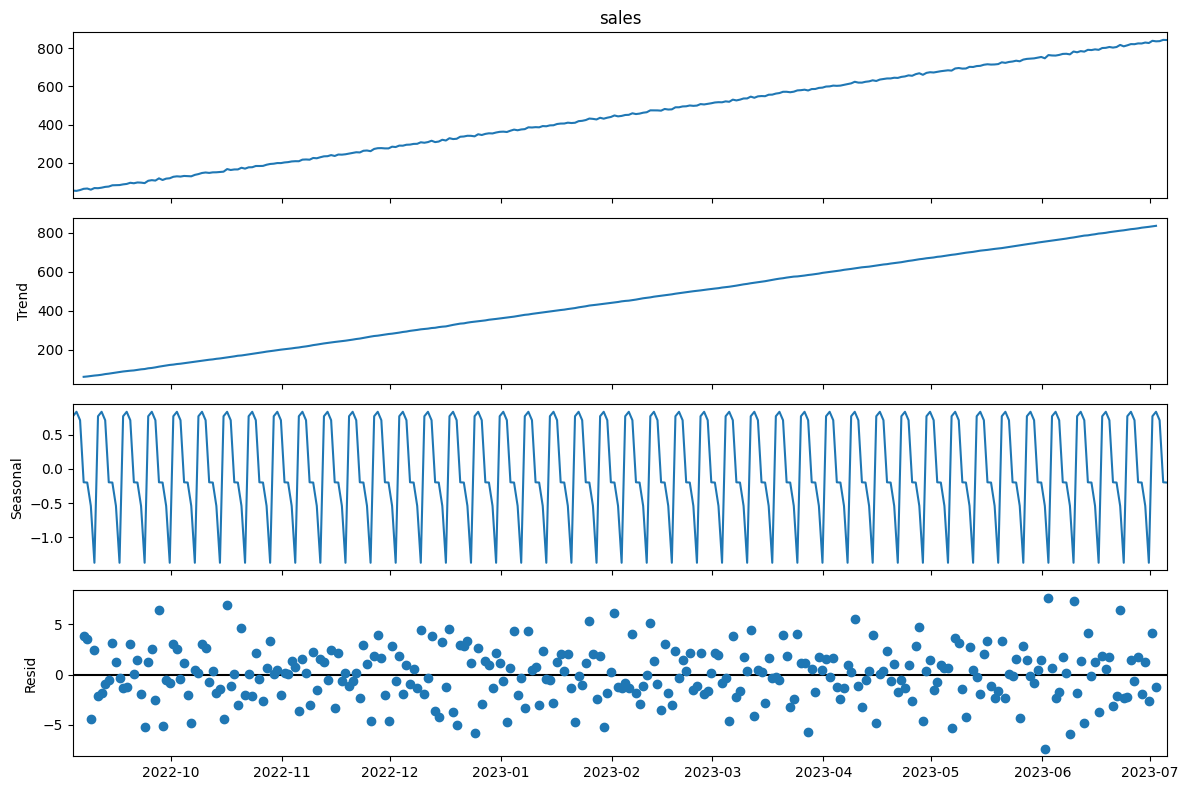

In [12]:
decomposition = seasonal_decompose(train, model="additive", period=7)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

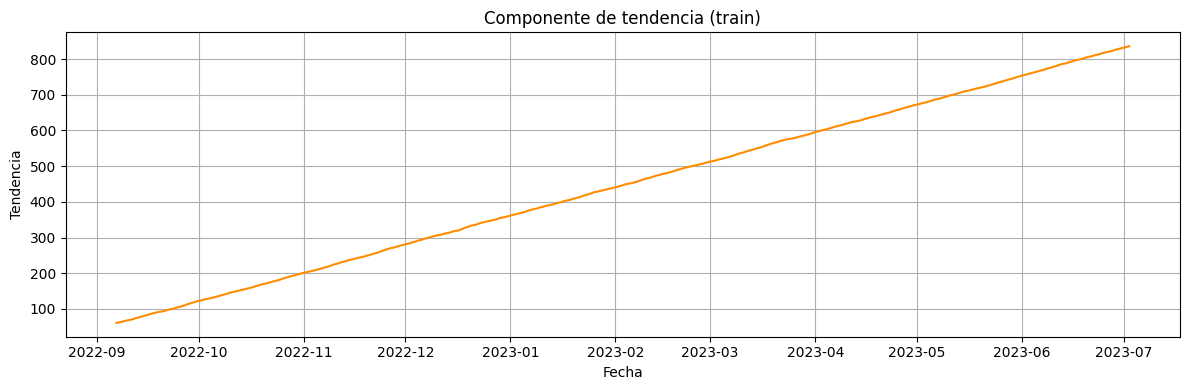

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(decomposition.trend, color="darkorange")
plt.title("Componente de tendencia (train)")
plt.xlabel("Fecha")
plt.ylabel("Tendencia")
plt.grid(True)
plt.tight_layout()
plt.show()

### Analizar ruido o variabilidad

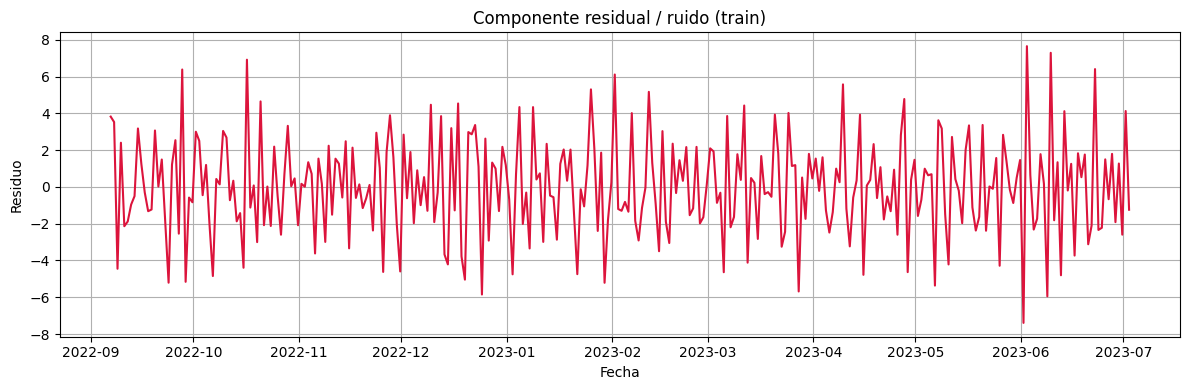

In [14]:
plt.figure(figsize=(12, 4))
plt.plot(decomposition.resid, color="crimson")
plt.title("Componente residual / ruido (train)")
plt.xlabel("Fecha")
plt.ylabel("Residuo")
plt.grid(True)
plt.tight_layout()
plt.show()

### Pregunta 4: ¿Existe variabilidad o presencia de ruido?

Sí, existe variabilidad o presencia de ruido en la serie, ya que la componente residual muestra fluctuaciones alrededor de cero y algunos picos aislados.

# Paso 3: Entrena un ARIMA

En este caso usaremos SARIMAX

### Búsqueda de hiperparámetros para SARIMAX

In [15]:
candidate_orders = [(1, 1, 0),(0, 1, 1),(1, 1, 1),(2, 1, 1),(1, 1, 2),(2, 1, 2)]
seasonal_scenarios = {
    "sin_estacionalidad": (0, 0, 0, 0),
    "estacionalidad_semanal": (1, 1, 1, 7)
}

In [16]:
rows = []
fitted_models = {}

for scenario_name, seasonal_order in seasonal_scenarios.items():
    for order in candidate_orders:
        try:
            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            result = model.fit(disp=False)
            pred = result.get_forecast(steps=len(test)).predicted_mean

            mae = mean_absolute_error(test, pred)
            rmse = sqrt(np.mean((test - pred) ** 2))

            rows.append({
                "escenario": scenario_name,
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": result.aic,
                "MAE": mae,
                "RMSE": rmse
            })

            fitted_models[(scenario_name, order, seasonal_order)] = result

        except Exception as e:
            print(f"Error con escenario={scenario_name}, order={order}: {e}")
            continue

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [17]:
results = pd.DataFrame(rows)
# Ordenar priorizando el mejor RMSE
results = (
    results
    .sort_values(by=["RMSE", "MAE", "AIC"], ascending=[True, True, True])
    .reset_index(drop=True)
)

display(results)

,escenario,order,seasonal_order,AIC,MAE,RMSE
0,sin_estacionalidad,"(2, 1, 1)","(0, 0, 0, 0)",1655.643463,2.148233,2.721926
1,estacionalidad_semanal,"(1, 1, 0)","(1, 1, 1, 7)",1586.617371,2.218483,2.811310
2,estacionalidad_semanal,"(0, 1, 1)","(1, 1, 1, 7)",1474.825359,2.301245,2.872079
3,estacionalidad_semanal,"(1, 1, 1)","(1, 1, 1, 7)",1472.520731,2.339279,2.905030
4,estacionalidad_semanal,"(2, 1, 1)","(1, 1, 1, 7)",1474.508433,2.340005,2.905367
5,estacionalidad_semanal,"(1, 1, 2)","(1, 1, 1, 7)",1469.256497,2.340210,2.905495
6,estacionalidad_semanal,"(2, 1, 2)","(1, 1, 1, 7)",1471.073877,2.343199,2.906761
7,sin_estacionalidad,"(1, 1, 2)","(0, 0, 0, 0)",1578.791347,2.551825,3.131530
8,sin_estacionalidad,"(2, 1, 2)","(0, 0, 0, 0)",1548.855912,2.575154,3.159333
9,sin_estacionalidad,"(1, 1, 1)","(0, 0, 0, 0)",1759.300845,3.231937,4.023269


In [18]:
best_row = results.iloc[0]

best_scenario = best_row["escenario"]
best_order = tuple(best_row["order"])
best_seasonal_order = tuple(best_row["seasonal_order"])

print("Mejor escenario:", best_scenario)
print("Mejor order:", best_order)
print("Mejor seasonal_order:", best_seasonal_order)

Mejor escenario: sin_estacionalidad
Mejor order: (2, 1, 1)
Mejor seasonal_order: (0, 0, 0, 0)


In [19]:
best_by_scenario = (
    results.sort_values(["escenario", "RMSE", "MAE", "AIC"])
           .groupby("escenario", as_index=False)
           .first()
)

display(best_by_scenario)

,escenario,order,seasonal_order,AIC,MAE,RMSE
0,estacionalidad_semanal,"(1, 1, 0)","(1, 1, 1, 7)",1586.617371,2.218483,2.811310
1,sin_estacionalidad,"(2, 1, 1)","(0, 0, 0, 0)",1655.643463,2.148233,2.721926


### Conclusión aplicando SARIMAX:
Al comparar ambos escenarios, el mejor desempeño en el conjunto de prueba se obtuvo con el modelo sin estacionalidad y parámetros (2,1,1). Esto sugiere que, para esta serie, incorporar una estacionalidad semanal no aportó una mejora real en la predicción final.

## Evaluación del mejor modelo

In [20]:
best_model = fitted_models[(best_scenario, best_order, best_seasonal_order)]

test_forecast = best_model.get_forecast(steps=len(test))
test_pred = test_forecast.predicted_mean
test_ci = test_forecast.conf_int()

mae = mean_absolute_error(test, test_pred)
rmse = sqrt(np.mean((test - test_pred) ** 2))

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE : 2.148
RMSE: 2.722


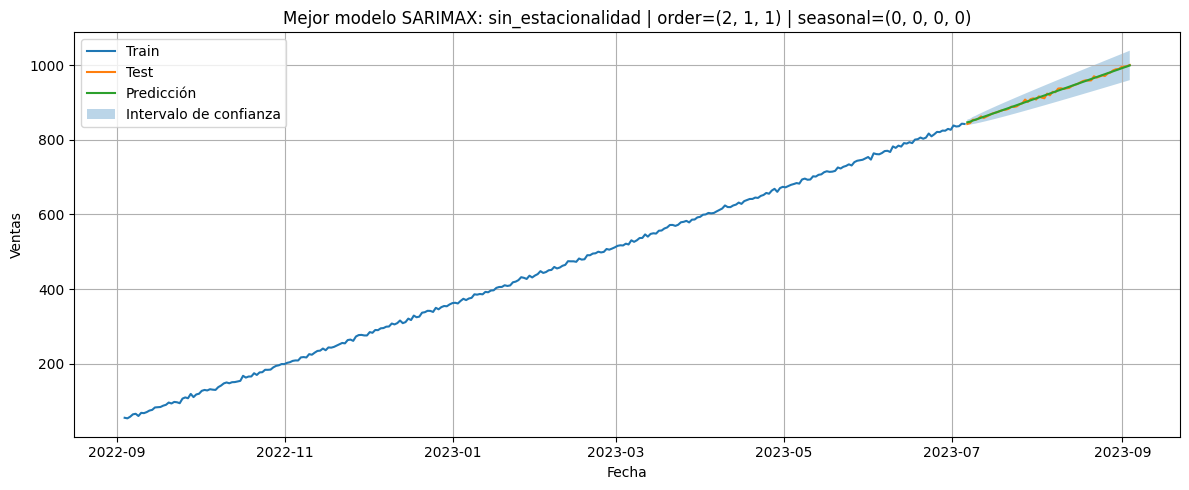

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, test_pred, label="Predicción")

plt.fill_between(
    test.index,
    test_ci.iloc[:, 0],
    test_ci.iloc[:, 1],
    alpha=0.3,
    label="Intervalo de confianza"
)

plt.title(f"Mejor modelo SARIMAX: {best_scenario} | order={best_order} | seasonal={best_seasonal_order}")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Para la evaluación final se recuperó el mejor modelo ajustado y se generó un pronóstico sobre el conjunto de Test. Se utilizaron como métricas el MAE y el RMSE, y además se calcularon intervalos de confianza para visualizar la incertidumbre asociada a las predicciones.

## Entrenar modelo final y pronosticar 60 días futuros

In [22]:
final_model = SARIMAX(
    ts,
    order=(2, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_model_fit = final_model.fit(disp=False)

print(final_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  366
Model:               SARIMAX(2, 1, 1)   Log Likelihood                -980.414
Date:                Mon, 13 Apr 2026   AIC                           1968.828
Time:                        02:59:57   BIC                           1984.406
Sample:                    09-03-2022   HQIC                          1975.020
                         - 09-03-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4569      0.049      9.403      0.000       0.362       0.552
ar.L2          0.5431      0.048     11.225      0.000       0.448       0.638
ma.L1         -1.0000    282.398     -0.004      0.9

### Pronósticamos los próximos 60 días

In [23]:
future_steps = 60

future_forecast = final_model_fit.get_forecast(steps=future_steps)
future_pred = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()

print(future_pred.head(10))

2023-09-04 17:10:08.079328    1002.798576
2023-09-05 17:10:08.079328    1005.558027
2023-09-06 17:10:08.079328    1008.076582
2023-09-07 17:10:08.079328    1010.726028
2023-09-08 17:10:08.079328    1013.304445
2023-09-09 17:10:08.079328    1015.921497
2023-09-10 17:10:08.079328    1018.517625
2023-09-11 17:10:08.079328    1021.125176
2023-09-12 17:10:08.079328    1023.726582
2023-09-13 17:10:08.079328    1026.331384
Freq: D, Name: predicted_mean, dtype: float64


In [24]:
future_index = pd.date_range(
    start=ts.index[-1] + pd.Timedelta(days=1),
    periods=future_steps,
    freq="D"
)
future_pred.index = future_index
future_ci.index = future_index

print("Última fecha de la serie histórica:", ts.index[-1])
print("Primera fecha futura del pronóstico:", future_index[0])
print("Última fecha futura del pronóstico:", future_index[-1])
print("Cantidad de fechas futuras generadas:", len(future_index))
print("\nPrimeras 5 fechas futuras:")
print(future_index[:5])

Última fecha de la serie histórica: 2023-09-03 17:10:08.079328
Primera fecha futura del pronóstico: 2023-09-04 17:10:08.079328
Última fecha futura del pronóstico: 2023-11-02 17:10:08.079328
Cantidad de fechas futuras generadas: 60

Primeras 5 fechas futuras:
DatetimeIndex(['2023-09-04 17:10:08.079328', '2023-09-05 17:10:08.079328',
               '2023-09-06 17:10:08.079328', '2023-09-07 17:10:08.079328',
               '2023-09-08 17:10:08.079328'],
              dtype='datetime64[us]', freq='D')


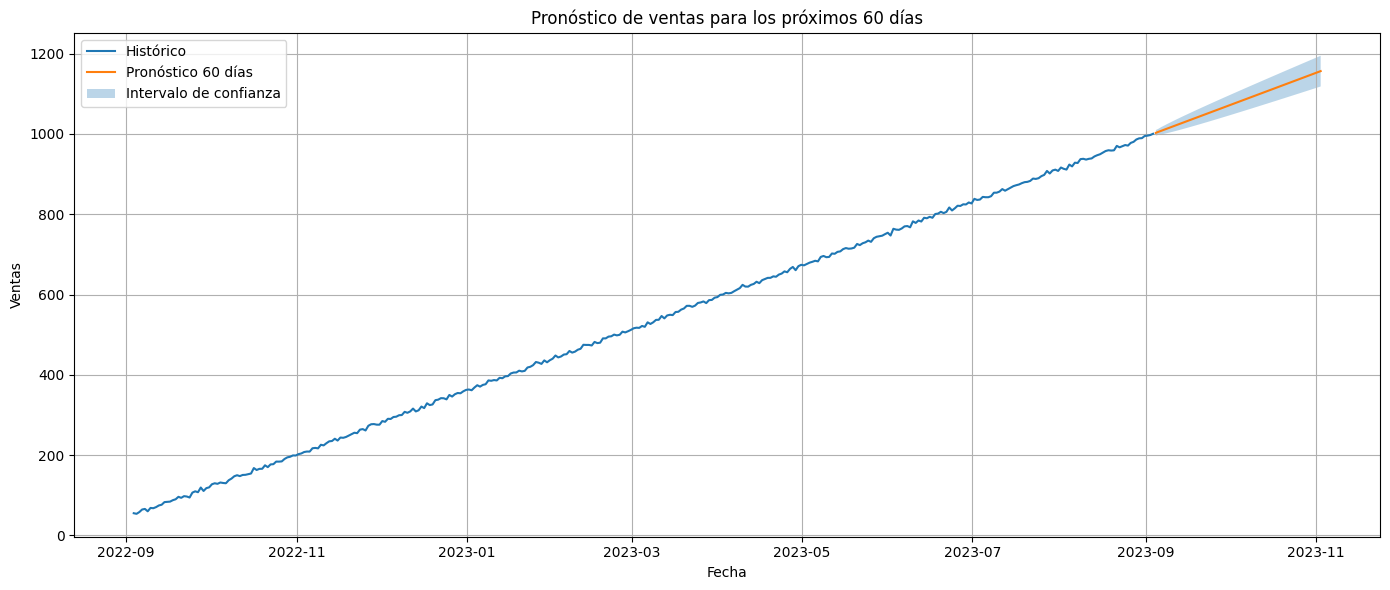

In [25]:
plt.figure(figsize=(14, 6))

# Serie histórica
plt.plot(ts.index, ts, label="Histórico")

# Pronóstico futuro
plt.plot(future_pred.index, future_pred, label="Pronóstico 60 días")

# Intervalo de confianza
plt.fill_between(
    future_ci.index,
    future_ci.iloc[:, 0],
    future_ci.iloc[:, 1],
    alpha=0.3,
    label="Intervalo de confianza"
)

plt.title("Pronóstico de ventas para los próximos 60 días")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Mostramos las 60 predicciones realizadas

In [26]:
forecast_df = pd.DataFrame({
    "forecast": future_pred,
    "lower_ci": future_ci.iloc[:, 0],
    "upper_ci": future_ci.iloc[:, 1]
})

display(forecast_df.head(10))
display(forecast_df.tail(10))

,forecast,lower_ci,upper_ci
2023-09-04 17:10:08.079328,1002.798576,995.783668,1009.813484
2023-09-05 17:10:08.079328,1005.558027,997.837595,1013.278460
2023-09-06 17:10:08.079328,1008.076582,998.710718,1017.442446
2023-09-07 17:10:08.079328,1010.726028,1000.464463,1020.987594
2023-09-08 17:10:08.079328,1013.304445,1001.969547,1024.639342
2023-09-09 17:10:08.079328,1015.921497,1003.727481,1028.115513
2023-09-10 17:10:08.079328,1018.517625,1005.453472,1031.581778
2023-09-11 17:10:08.079328,1021.125176,1007.273916,1034.976436
2023-09-12 17:10:08.079328,1023.726582,1009.109880,1038.343284
2023-09-13 17:10:08.079328,1026.331384,1010.992410,1041.670358


,forecast,lower_ci,upper_ci
2023-10-24 17:10:08.079328,1133.112240,1098.120991,1168.103490
2023-10-25 17:10:08.079328,1135.717463,1100.349316,1171.085610
2023-10-26 17:10:08.079328,1138.322724,1102.580057,1174.065390
2023-10-27 17:10:08.079328,1140.928022,1104.813141,1177.042904
2023-10-28 17:10:08.079328,1143.533359,1107.048496,1180.018223
2023-10-29 17:10:08.079328,1146.138734,1109.286055,1182.991413
2023-10-30 17:10:08.079328,1148.744148,1111.525755,1185.962541
2023-10-31 17:10:08.079328,1151.349599,1113.767533,1188.931666
2023-11-01 17:10:08.079328,1153.955089,1116.011331,1191.898847
2023-11-02 17:10:08.079328,1156.560617,1118.257092,1194.864141


# Guardar modelo

In [27]:
import os
import joblib

save_path = "models/final_sarimax_sales.pkl"
os.makedirs("models", exist_ok=True)

joblib.dump(final_model_fit, save_path)

print(f"El modelo final fue guardado correctamente en: {save_path}")

El modelo final fue guardado correctamente en: models/final_sarimax_sales.pkl
